In [20]:
# Load and check what is inside
import os
import torch

from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too
from maren_data.helpers import choose_data_params

# Save the ones that ran correctly
successful_models = {}
data = "randman"
seeds = [1, 2, 3, 4, 5]
percent_data = [0.25, 0.5, 1.0]
if data == "shd":
    num_hidden = [256, 128, 64]
elif data == "randman":
    num_hidden = [20, 10, 5]
# Add model classes to dictionary with test accuracy values (we'll take averages at the end)
for model_name in MODEL_CLASSES.keys():
    print(f"Evaluating model: {model_name}")
    successful_models[model_name] = {}
    if "Hybrid" in model_name:
        percents = [0.25, 0.5, 0.75]
    else:
        percents = [None]
    for percent in percents:
        successful_models[model_name][percent] = {}
        for pct_data in percent_data:
            successful_models[model_name][percent][pct_data] = {}
            for n_hidden in num_hidden:
                successful_models[model_name][percent][pct_data][n_hidden] = []
                for seed in seeds:
                    if data == "shd":
                        path = f"/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/tpe_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/best_model_of_study.ckpt"
                    elif data == "randman":
                        path = f"/vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/{model_name}/recurrent_True/seed_{seed}/tpe_sampler/20_hidden/{pct_data}_pct_data/None_percent_snn/best_model_of_study.ckpt"
                    if not os.path.exists(path):
                        # print(f"Path does not exist for {seed, model_name}, skipping...")
                        continue
                    else:
                        # print(f"Loading model from {path}")
                        # ckpt = torch.load(path, map_location="cpu")
                        # # Print hyperparameters
                        # hparams = ckpt['hyper_parameters']  
                        # print("Hyperparameters:", hparams)
                        successful_models[model_name][percent][pct_data][n_hidden].append(seed)


Evaluating model: SNN
Evaluating model: ANN_with_LIF_output
Evaluating model: NSN_with_LIF_output
Evaluating model: Hybrid_RNN_SNN_rec
Evaluating model: Hybrid_NSN_SNN_rec
Evaluating model: Hybrid_RNN_SNN_V1_same_layer
Evaluating model: Hybrid_NSN_SNN_V1_same_layer
Evaluating model: Hybrid_NSN_SNN_V1_Flexible_Spiking


In [21]:
successful_models # Not sure what's happening! Possibly all the same optuna issue? Start with NSN and then fix the rest

{'SNN': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [1, 2, 3, 4, 5], 10: [1, 2, 3, 4, 5], 5: [1, 2, 3, 4, 5]}}},
 'ANN_with_LIF_output': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'NSN_with_LIF_output': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'Hybrid_RNN_SNN_rec': {0.25: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.5: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.75: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'Hybrid_NSN_SNN_rec': {0.25: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.5: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.75

In [22]:
from test_visualizations.utils import get_randman_test_data, get_shd_test_data
if data == "shd":
    test_loader = get_shd_test_data()
elif data == "randman":
    test_loader = get_randman_test_data()
else:
    raise ValueError("Data must be 'shd' or 'randman'")

In [23]:
from tqdm import tqdm

def compute_accuracy(model, test_loader=test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.test_accuracy.reset()
    model.to(device)
    model.zero_grad()
    # criterion = nn.CrossEntropyLoss()
    for inputs, targets in tqdm(test_loader, desc="Testing"):
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        model.test_accuracy.update(logit_output, targets)
    test_acc = model.test_accuracy.compute().item()
    return test_acc

In [24]:
successful_models

{'SNN': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [1, 2, 3, 4, 5], 10: [1, 2, 3, 4, 5], 5: [1, 2, 3, 4, 5]}}},
 'ANN_with_LIF_output': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'NSN_with_LIF_output': {None: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'Hybrid_RNN_SNN_rec': {0.25: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.5: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.75: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}}},
 'Hybrid_NSN_SNN_rec': {0.25: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.5: {0.25: {20: [], 10: [], 5: []},
   0.5: {20: [], 10: [], 5: []},
   1.0: {20: [], 10: [], 5: []}},
  0.75

In [25]:
final_test_accuracies = {}

for model_name, percent_dict in successful_models.items():
    final_test_accuracies[model_name] = {}
    for percent, pct_data_dict in percent_dict.items():
        final_test_accuracies[model_name][percent] = {}
        for pct_data, n_hidden_dict in pct_data_dict.items():
            final_test_accuracies[model_name][percent][pct_data] = {}
            for n_hidden, seeds in n_hidden_dict.items():
                final_test_accuracies[model_name][percent][pct_data][n_hidden] = {}
                test_accuracies = []
                for seed in seeds:
                    if data == "shd":
                        path = f"/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/tpe_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/best_model_of_study.ckpt"
                    elif data == "randman":
                        path = f"/vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/{model_name}/recurrent_True/seed_{seed}/tpe_sampler/20_hidden/{pct_data}_pct_data/None_percent_snn/best_model_of_study.ckpt"
                    model_class = MODEL_CLASSES[model_name]
                    print(f"Loading model from {path}")
                    model = model_class.load_from_checkpoint(path, strict=False)
                    test_acc = compute_accuracy(model, test_loader=test_loader)
                    test_accuracies.append(test_acc)
                final_test_accuracies[model_name][percent][pct_data][n_hidden] = test_accuracies


Loading model from /vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_1/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 1/1 [00:00<00:00, 60.79it/s]


Loading model from /vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_2/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 1/1 [00:00<00:00, 59.31it/s]


Loading model from /vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/SNN/recurrent_True/seed_3/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


...

Testing: 100%|██████████| 1/1 [00:00<00:00, 56.41it/s]


Loading model from /vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/Hybrid_NSN_SNN_V1_Flexible_Spiking/recurrent_True/seed_4/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 1/1 [00:00<00:00, 55.14it/s]


Loading model from /vast/nar8991/training_results/randman/1_d/2_classes/3/cross_entropy/Hybrid_NSN_SNN_V1_Flexible_Spiking/recurrent_True/seed_5/tpe_sampler/20_hidden/1.0_pct_data/None_percent_snn/best_model_of_study.ckpt


Testing: 100%|██████████| 1/1 [00:00<00:00, 54.89it/s]


In [26]:
# final_test_accuracies = {}
# for model_name in successful_models.keys():
#     final_test_accuracies[model_name] = {}
#     for percent in successful_models[model_name].keys():
#         final_test_accuracies[model_name][percent] = []
#         for seed in successful_models[model_name][percent]:
#             path = f"/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/tpe_sampler/256_hidden/1.0_pct_data/{percent}_percent_snn/best_model_of_study.ckpt"
#             model_class = MODEL_CLASSES[model_name]
#             print(f"Loading model from {path}")
#             model = model_class.load_from_checkpoint(path, strict=False)
#             test_acc = compute_accuracy(model, test_loader=test_loader)
#             final_test_accuracies[model_name][percent].append(test_acc)
#             print(f"Model: {model_name}, Percent: {percent}, Seed: {seed}, Test Acc: {test_acc}")

In [27]:
final_test_accuracies.keys()

dict_keys(['SNN', 'ANN_with_LIF_output', 'NSN_with_LIF_output', 'Hybrid_RNN_SNN_rec', 'Hybrid_NSN_SNN_rec', 'Hybrid_RNN_SNN_V1_same_layer', 'Hybrid_NSN_SNN_V1_same_layer', 'Hybrid_NSN_SNN_V1_Flexible_Spiking'])

In [28]:

# Take the dictionary and convert it to a dataframe
import pandas as pd

remapping = {
    "SNN": "SNN",
    "ANN_with_LIF_output": "RNN",
    "NSN_with_LIF_output": "Nonspiking",
    "Hybrid_RNN_SNN_rec": "Network-to-Network RNN",
    "Hybrid_NSN_SNN_rec": "Network-to-Network Nonspiking",
    "Hybrid_RNN_SNN_V1_same_layer": "Same Layer RNN",
    "Hybrid_NSN_SNN_V1_same_layer": "Same Layer Nonspiking",
}


def convert_dict_to_df(final_test_accuracies):
    df_rows = []
    for model_name, percent_dict in final_test_accuracies.items():
        new_model_name = remapping.get(model_name, model_name)
        model_name = new_model_name
        for percent_snn, percent_data in percent_dict.items():
            for percent_data, hidden_data in percent_data.items():
                for hidden_size, accuracies in hidden_data.items():
                    if len(accuracies) > 0:
                        avg_acc = sum(accuracies) / len(accuracies)
                        std_acc = (sum((x - avg_acc) ** 2 for x in accuracies) / len(accuracies)) ** 0.5
                        df_rows.append({
                            "Model": model_name,
                            "Percent_SNN": percent_snn,
                            "Percent_Data": percent_data,
                            "Hidden_Size": hidden_size,
                            "mean_value": avg_acc,
                            "std_value": std_acc,
                            "count": len(accuracies)
                        })
                    else:
                        df_rows.append({
                            "Model": model_name,
                            "Percent_SNN": percent_snn,
                            "Percent_Data": percent_data,
                            "Hidden_Size": hidden_size,
                            "mean_value": None,
                            "std_value": None,
                            "count": 0
                        })
    results_df = pd.DataFrame(df_rows)
    results_df['run_group'] = results_df['Model'] + "_pct_" + results_df['Percent_SNN'].astype(str)
    results_df['metric'] = 'Test Accuracy'
    # Drop rows where mean_value is None
    # results_df.dropna(subset=['mean_value'], inplace=True)
    return results_df

results_df = convert_dict_to_df(final_test_accuracies)

In [38]:
results_df

,Model,Percent_SNN,Percent_Data,Hidden_Size,mean_value,std_value,count,run_group,metric
0,SNN,NaN,0.25,20,NaN,NaN,0,SNN_pct_nan,Test Accuracy
1,SNN,NaN,0.25,10,NaN,NaN,0,SNN_pct_nan,Test Accuracy
2,SNN,NaN,0.25,5,NaN,NaN,0,SNN_pct_nan,Test Accuracy
3,SNN,NaN,0.50,20,NaN,NaN,0,SNN_pct_nan,Test Accuracy
4,SNN,NaN,0.50,10,NaN,NaN,0,SNN_pct_nan,Test Accuracy
...,...,...,...,...,...,...,...,...,...
157,Hybrid_NSN_SNN_V1_Flexible_Spiking,0.75,0.50,10,NaN,NaN,0,Hybrid_NSN_SNN_V1_Flexible_Spiking_pct_0.75,Test Accuracy
158,Hybrid_NSN_SNN_V1_Flexible_Spiking,0.75,0.50,5,NaN,NaN,0,Hybrid_NSN_SNN_V1_Flexible_Spiking_pct_0.75,Test Accuracy
159,Hybrid_NSN_SNN_V1_Flexible_Spiking,0.75,1.00,20,0.8235,0.139074,5,Hybrid_NSN_SNN_V1_Flexible_Spiking_pct_0.75,Test Accuracy
160,Hybrid_NSN_SNN_V1_Flexible_Spiking,0.75,1.00,10,0.8235,0.139074,5,Hybrid_NSN_SNN_V1_Flexible_Spiking_pct_0.75,Test Accuracy


In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _plot_bars(ax, x_offset, values, std_values, bar_width, labels, alpha=0.8, capsize=5):
    bars = ax.bar(x_offset, values, bar_width, yerr=std_values, capsize=capsize, label=labels, alpha=alpha)
    return bars

def _annotate_bars(ax, bars, values, std_values, extra_labels=None):
    for j, bar in enumerate(bars):
        value = values[j]
        if value > 0 and not pd.isna(value):
            text_y_position = value + (std_values[j] if std_values[j] > 0 else 0) + 0.01
            label_text = f'{value:.3f}'
            if extra_labels and extra_labels[j]:
                label_text += extra_labels[j]
            ax.text(bar.get_x() + bar.get_width()/2., text_y_position,
                    label_text, ha='center', va='bottom', fontsize=8, rotation=0)

def plot_metric_distribution(df_means, metrics, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    has_counts = 'count' in df_means.columns

    run_groups = sorted(df_means['run_group'].unique())
    run_group_labels = []
    for group in run_groups:
        group_df = df_means[df_means['run_group'] == group]
        lr_for_label = None
        if 'val_accuracy' in group_df['metric'].values and 'learning_rate' in group_df.columns:
            lr_row = group_df[group_df['metric'] == 'val_accuracy'].iloc[0]
            lr_for_label = lr_row['learning_rate']
        elif not group_df.empty and 'learning_rate' in group_df.columns:
            lr_for_label = group_df['learning_rate'].iloc[0]
        if lr_for_label is not None:
            run_group_labels.append(f"{group}\n(lr: {lr_for_label:.1e})")
        else:
            run_group_labels.append(group)

    bar_width = 0.8 / len(metrics)
    x_positions = np.arange(len(run_groups))

    for i, metric in enumerate(metrics):
        df_metric = df_means[df_means['metric'] == metric]
        values, std_values, counts = [], [], []
        for group in run_groups:
            group_data = df_metric[df_metric['run_group'] == group]
            if not group_data.empty:
                values.append(group_data['mean_value'].iloc[0])
                std_values.append(group_data['std_value'].iloc[0])
                counts.append(group_data['count'].iloc[0] if has_counts else None)
            else:
                values.append(0)
                std_values.append(0)
                counts.append(None)
        x_offset = x_positions + (i - len(metrics)/2 + 0.5) * bar_width
        bars = _plot_bars(ax, x_offset, values, std_values, bar_width, metric)
        extra_labels = [f'\n(n={int(c)})' if has_counts and c is not None else '' for c in counts]
        _annotate_bars(ax, bars, values, std_values, extra_labels)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(run_group_labels, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.set_xlabel('Run Group (with Learning Rate)')
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax

def plot_metric_distribution_param_based(param_name, param_range, df_means, metric, title=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    run_groups = sorted(df_means['run_group'].unique())
    df_metric = df_means[df_means['metric'] == metric]
    bar_width = 0.8 / len(run_groups)
    x_positions = np.arange(len(param_range))

    for i, group in enumerate(run_groups):
        df_group = df_metric[df_metric['run_group'] == group]
        values, std_values, lrs, counts = [], [], [], []
        for p_val in param_range:
            param_data = df_group[df_group[param_name] == p_val]
            if not param_data.empty:
                values.append(param_data['mean_value'].iloc[0])
                std_values.append(param_data['std_value'].iloc[0])
                lrs.append(param_data['learning_rate'].iloc[0] if 'learning_rate' in param_data.columns else None)
                counts.append(param_data['count'].iloc[0] if 'count' in param_data.columns else None)
            else:
                values.append(0)
                std_values.append(0)
                lrs.append(None)
                counts.append(None)
        x_offset = x_positions + (i - len(run_groups)/2 + 0.5) * bar_width
        bars = _plot_bars(ax, x_offset, values, std_values, bar_width, group)
        extra_labels = [
            (f'\n(lr: {lrs[j]:.1e})' if lrs[j] is not None else '') +
            (f'\n(n={int(counts[j])})' if counts[j] is not None else '')
            for j in range(len(values))
        ]
        _annotate_bars(ax, bars, values, std_values, extra_labels)

    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right')
    ax.set_title(title if title else f'{metric} Distribution by {param_name}')
    ax.set_ylabel(metric)
    ax.set_xlabel(param_name)
    ax.legend(title='Run Group')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax


In [31]:
filtered_df = results_df[(results_df['Percent_Data']==1.0) & (results_df['Hidden_Size']==256)]

<Axes: title={'center': 'Test Accuracy by Model and Percent SNN'}, xlabel='Run Group (with Learning Rate)', ylabel='Value'>

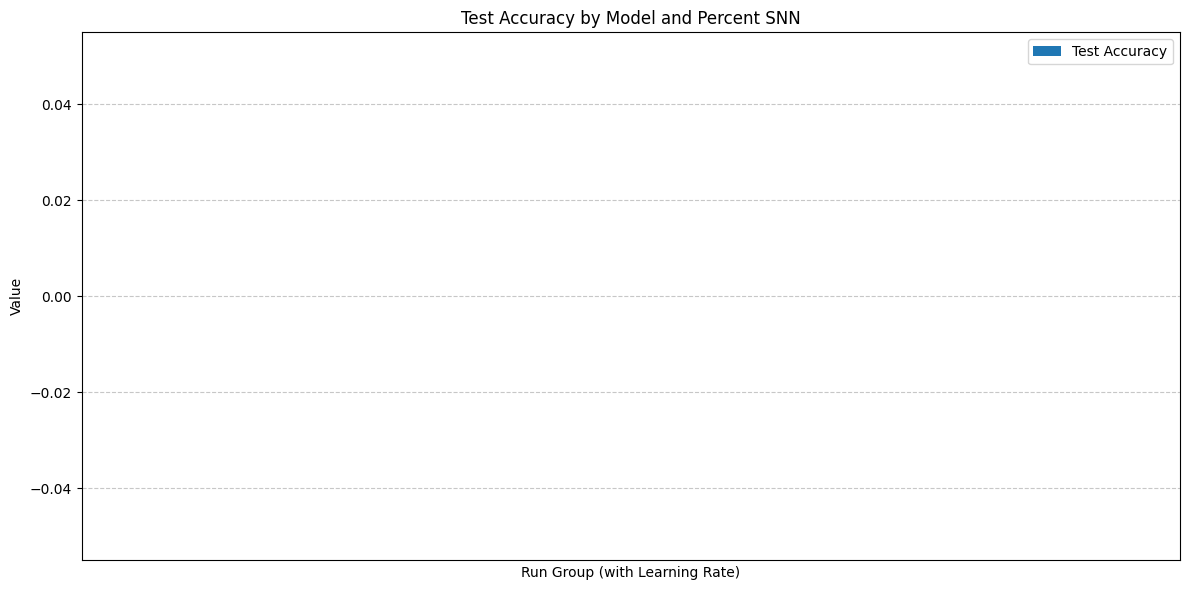

In [32]:
# Need to rerun so we do more trials, they're still too low for SNN
plot_metric_distribution(filtered_df, metrics=["Test Accuracy"], title="Test Accuracy by Model and Percent SNN")

In [33]:
filtered_df = results_df[(results_df['Percent_Data']==1.0)]

ZeroDivisionError: float division by zero

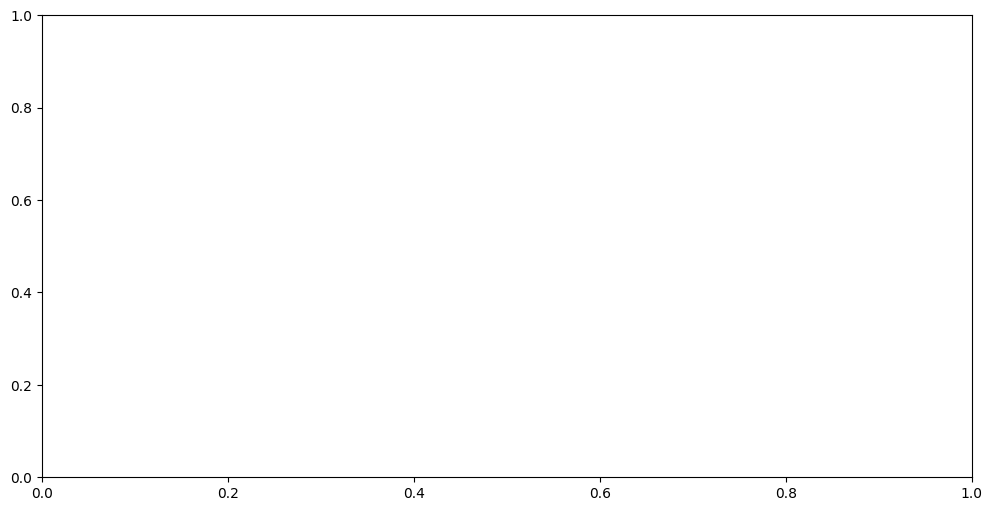

In [37]:
plot_metric_distribution_param_based("Hidden_Size", num_hidden, filtered_df, metric="Test Accuracy", title="Test Accuracy by Hidden Size and Model (Percent Data = 1.0)")

ZeroDivisionError: float division by zero

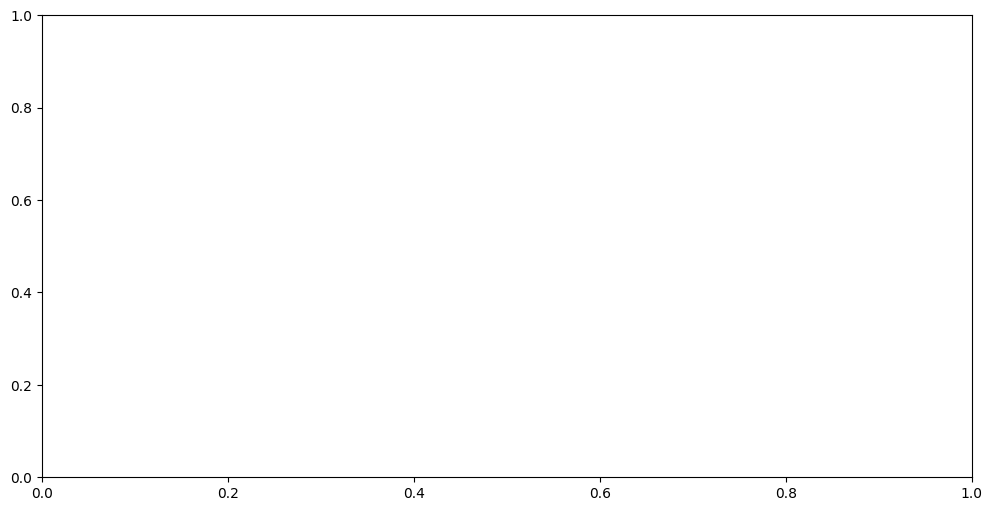

In [35]:
filtered_df = results_df[(results_df['Hidden_Size']==256)]
plot_metric_distribution_param_based("Percent_Data", [0.25, 0.5, 0.75, 1.0], filtered_df, metric="Test Accuracy", title="Test Accuracy by Percent Data and Model")

In [ ]:
# For different sizes -> 


In [ ]:
# Accuracy seems too low still -> will need to increase the number of trials if we want to keep this version
# ALSO -> need to adjust where we're saving the models (vast given my home issues)
# ALSO -> SNN test accuracy is still too low vs. the Zenke and Vogels baseline so double check my implementation again



# To do -> start with the randman instead to check everything is working, then switch over
